# Laboratorio de regresión logística

|                |   |
:----------------|---|
| **Nombre**     | Carlos Enrique Nieves Ochoa |
| **Fecha**      | 4 de octubre de 2026 |
| **Expediente** | 758210 |

La regresión logística es una herramienta utilizada para predecir respuestas cualitativas. Al igual que la regresión lineal, es un método sencillo que sirve como un punto de partida para técnicas más avanzadas. Por ejemplo, lo que se conoce como *redes neuronales* o *red de perceptrones multicapa* no es más que una estructura de regresiones logísticas que se alimentan entre sí.

1. Descarga el archivo de créditos y carga los datos (Default.csv). Utiliza `pandas`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from scipy.stats import norm

# La primera columna es el número de fila, no un factor
df = pd.read_csv("Default.csv", index_col=0)
df.shape

(10000, 4)

2. Utiliza el comando `obj.head()`, donde `obj` es el nombre que le diste a los datos del archivo.

In [2]:
df.head()

,default,student,balance,income
rownames,,,,
1,No,No,729.526495,44361.625074
2,No,Yes,817.180407,12106.134700
3,No,No,1073.549164,31767.138947
4,No,No,529.250605,35704.493935
5,No,No,785.655883,38463.495879


El comando head arroja los primeras *n* líneas (por defecto 5) de los datos que están en el DataFrame.

3. Utiliza el comando `obj.describe()`.

In [3]:
df.describe()

,balance,income
count,10000.000000,10000.000000
mean,835.374886,33516.981876
std,483.714985,13336.639563
min,0.000000,771.967729
25%,481.731105,21340.462903
50%,823.636973,34552.644802
75%,1166.308386,43807.729272
max,2654.322576,73554.233495


El comando describe toma las columnas que tienen datos numéricos y saca datos estadísticos comunes:
- *n*
- media
- desviación estándar
- valor mínimo
- primer cuartil
- mediana
- tercer cuartil
- valor máximo

3. Vistos estos datos, ¿qué columnas existen en el DataFrame? ¿Qué tipo de datos contienen?

In [4]:
df.dtypes

default        str
student        str
balance    float64
income     float64
dtype: object

Las columnas son `default`, `student`, `balance` e `income`, las dos primeras son variables cualitativas con las categorías Yes y No, aunque al cargar el archivo aparecen como texto, `balance` e `income` son variables numéricas continuas.

4. Configura el tipo de dato de las columnas `default` y `student` para cambiarlos a variables categóricas.

`data[columna] = data[columna].astype("category")`

In [5]:
df["default"] = df["default"].astype("category")
df["student"] = df["student"].astype("category")
df.dtypes

default    category
student    category
balance     float64
income      float64
dtype: object

Imagina que trabajas en un banco y que se te entregan estos datos. Tu objetivo es crear un modelo que ayude a predecir si una persona que solicita un crédito lo va a pagar. Exploremos los datos un poco más antes de crear un modelo.

Veamos primero cómo es la distribución de los valores cuando una persona dejó de pagar y cuando siguió pagando. `Default` es el término utilizado para cuando una persona dejó de pagar.

5. Crea una gráfica de caja para las columnas `income` y `balance`, con los datos agrupados con la columna `default`. Utiliza el comando `obj.boxplot(column=____, by=_____)`

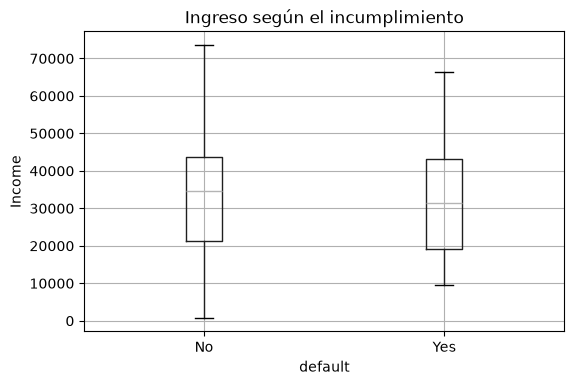

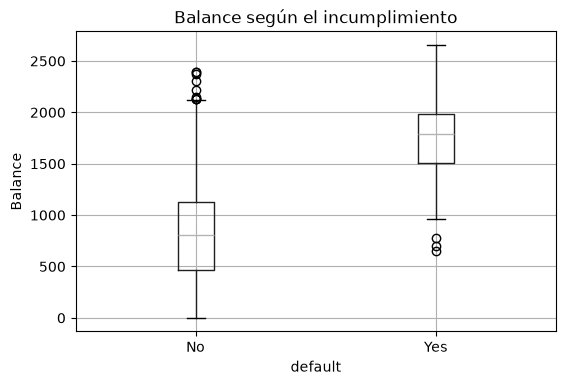

In [6]:
df.boxplot(column="income", by="default", figsize=(6, 4))
plt.suptitle("")
plt.title("Ingreso según el incumplimiento")
plt.ylabel("Income")
plt.show()

df.boxplot(column="balance", by="default", figsize=(6, 4))
plt.suptitle("")
plt.title("Balance según el incumplimiento")
plt.ylabel("Balance")
plt.show()

6. Crea una gráfica de dispersión donde el eje *x* sea la columna `balance` y el eje *y* la columna `income`. Utiliza el comando `obj.plot.scatter(x, y, c="default", colormap="PiYG_r", alpha=0.5)`.

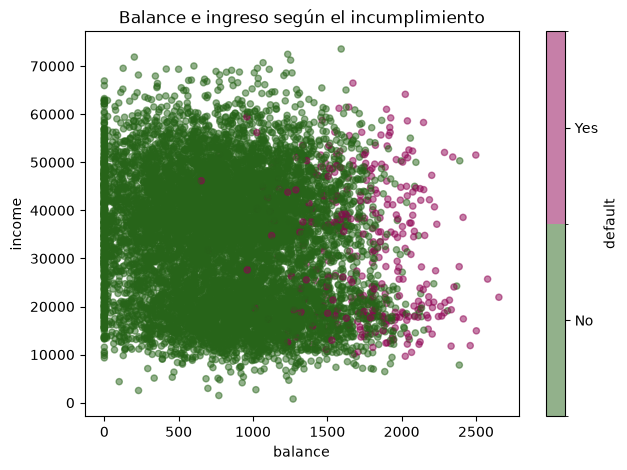

In [7]:
df.plot.scatter(
    x="balance", y="income", c="default",
    colormap="PiYG_r", alpha=0.5, figsize=(7, 5)
)
plt.title("Balance e ingreso según el incumplimiento")
plt.show()

La regresión (lineal o logística) se usa para encontrar una línea que ajuste los datos para tomar una decisión. La línea que buscamos en regresión logística es aquella que nos ayude a separar las diferentes categorías. 

<img style="float: left; " src="https://www.baeldung.com/wp-content/uploads/sites/4/2023/10/decision_boundary_curve.jpg" width="400px" />


## Regresión logística simple

Creemos un modelo simple donde sólo utilizamos una de los factores para predecir una respuesta. Quiero conocer la probabilidad de que una persona deje de pagar su crédito dado el balance que tiene en su cuenta.

$$ P(\text{default}=\text{Yes}|\text{balance}) $$

Por el momento la columna default no contiene valores numéricos, por lo que hay que transformar los datos. Como default es nuestra variable de respuesta (lo que queremos predecir) podemos nombrarla *y*.

Ejecuta el código `y = obj["default"] == "Yes"`. Extrae el factor `balance` en una variable *x*.

In [8]:
y = df["default"] == "Yes"
x = df["balance"]
X = df[["balance"]]

Crea un gráfico de dispersión donde el eje *x* sea `balance` y el eje *y* sea `default` transformado.

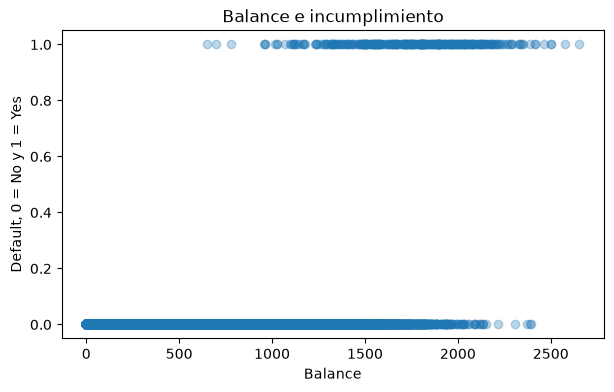

In [9]:
plt.figure(figsize=(7, 4))
plt.scatter(x, y, alpha=0.3)
plt.xlabel("Balance")
plt.ylabel("Default, 0 = No y 1 = Yes")
plt.title("Balance e incumplimiento")
plt.show()

La línea que utilizaremos para predecir la probabilidad es:

$$ p(x) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x)}} $$

Para nuestro ejemplo de pagos y balance:

$$ P(\text{default}=1|\text{balance}) = \frac{1}{1 + e^{-(\beta_0 + \beta_1  \text{balance})}} $$

Buscamos maximizar la probabilidad de que el modelo tome decisiones correctas. Es decir, que cuando `default` fue verdadero, que la predicción sea 100%, y que cuando `default` fue falso que la predicción sea 0%.

$$ \Pi_{i:y_i=1} p(x_i) \Pi_{i':y_{i'}} (1-p(x_{i'})) $$

La función de costo ya simplificada es la siguiente:

$$ J(\vec{\beta}) = -  \sum_{i=1}^n{[y_i \ln{(\hat{p}(x_i))} + (1-y_i)\ln{(1 - \hat{p}(x_i))}]}$$

Utiliza la clase `LogisticRegression` del módulo `linear_model` de la librería `sklearn` para estimar los parámetros del modelo.

In [10]:
modelo = LogisticRegression(C=1000000, max_iter=1000, tol=1e-8)
modelo.fit(X, y)

b0 = modelo.intercept_[0]
b1 = modelo.coef_[0][0]

print("Intercepto:", b0)
print("Coeficiente de balance:", b1)

Intercepto: -10.651330620737246
Coeficiente de balance: 0.005498916934907727


Muchos aspectos de la regresión logística son similares a la regresión lineal. Podemos medir la precisión de nuestros estimados calculando sus errores estándar. El objetivo de calcular estos errores es asegurar que hay una relación estadísticamente significativa entre el factor y la variable de respuesta.

Los errores estándar se obtienen con el siguiente procedimiento:

1. Calcula las predicciones utilizando los $\beta_0$ y $\beta_1$ encontrados.

In [11]:
p = 1 / (1 + np.exp(-(b0 + b1 * x)))
p.head()

rownames
1    0.001306
2    0.002113
3    0.008595
4    0.000434
5    0.001777
Name: balance, dtype: float64

2. Idealmente la probabilidad debería ser 100% o 0%. Si alguna predicción no fue absoluta significa que hay incertidumbre. Calcula $p(1-p)$ para todas tus predicciones.

In [12]:
w = p * (1 - p)
w.head()

rownames
1    0.001304
2    0.002108
3    0.008521
4    0.000434
5    0.001774
Name: balance, dtype: float64

3. Crea una matriz vacía y llena la diagonal con las probabilidades encontradas.

`V = np.diagflat(*p(1-p)*)`

In [13]:
V = np.diagflat(w)
V.shape

(10000, 10000)

4. Calcula la matriz de covarianza. (Dado que X es la matriz que contiene todos los factores)

`cov = np.linalg.inv(X.T @ V @ X)`

In [14]:
# La columna de unos corresponde al intercepto
X_diseno = np.hstack([np.ones((len(X), 1)), X.values])
cov = np.linalg.inv(X_diseno.T @ V @ X_diseno)
cov

array([[ 1.30442848e-01, -7.81757783e-05],
       [-7.81757783e-05,  4.85656859e-08]])

5. Los valores en la diagonal de la matriz de covarianza corresponden a la varianza de los factores. Utiliza los valores de la diagonal para calcular el error estándar.

`se = np.sqrt(np.diag(cov))`

In [15]:
se = np.sqrt(np.diag(cov))
print("Error estándar del intercepto:", se[0])
print("Error estándar de balance:", se[1])

Error estándar del intercepto: 0.3611687252397425
Error estándar de balance: 0.00022037623717439977


Ahora, revisemos si los estimados de nuestros coeficientes demuestran que hay una relación significativa entre los factores y la respuesta.

Calculamos el estadístico *z*

$$ z_j = \frac{\hat{\beta_j}}{\text{SE}(\hat{\beta_j})} $$

In [16]:
beta = np.array([b0, b1])
z_statistic = beta / se
print(z_statistic)

[-29.49128725  24.95240415]


Utilizamos el estadístico *z* para encontrar el *p-value*.

`from scipy.stats import norm`

`p_value = 2 * (1 - norm.cdf(abs(z_statistic)))`

In [17]:
p_value = 2 * (1 - norm.cdf(abs(z_statistic)))

tabla_balance = pd.DataFrame({
    "Coeficiente": beta,
    "Error estándar": se,
    "z": z_statistic,
    "p-value": p_value
}, index=["Intercepto", "balance"])

tabla_balance

,Coeficiente,Error estándar,z,p-value
Intercepto,-10.651331,0.361169,-29.491287,0.0
balance,0.005499,0.000220,24.952404,0.0


¿Es significativa la relación de los factores con la variable de respuesta?

Sí, balance tiene un p-value menor a 0,05 y su coeficiente es positivo, hay evidencia de una relación entre un mayor balance y una mayor probabilidad de incumplimiento, el p-value aparece como 0 por la precisión del cálculo, no porque sea exactamente cero

Repite el procedimiento con el factor `student`. 
1. Transforma el factor de {"Yes", "No"} a {1, 0}.
2. Estima los coeficientes. 
3. Calcula el error estándar de tus estimaciones.
   1. Usa tu modelo para encontrar $\hat{p}(X)$
   2. Calcula el error $p(1-p)$
   3. Calcula la matriz de covarianza
   4. Extrae el error estándar
5. Argumenta si los factores son significativos utilizando el *p-value*.
   1. Utiliza el error estándar para calcular el estadístico *z*
   2. Calcula el *p-value*
   3. ¿Son significativos?


**Transformar student y ajustar el modelo**

In [18]:
X_student = pd.DataFrame({
    "student": (df["student"] == "Yes").astype(int)
})

modelo_student = LogisticRegression(C=1000000, max_iter=1000, tol=1e-8)
modelo_student.fit(X_student, y)

beta_student = np.hstack([
    modelo_student.intercept_, modelo_student.coef_[0]
])
print("Intercepto y coeficiente de student:", beta_student)

Intercepto y coeficiente de student: [-3.50412775  0.40488724]


**Calcular probabilidades, covarianza y errores estándar**

In [19]:
# Reutilizar V evita conservar varias matrices grandes
V = None
p_student = modelo_student.predict_proba(X_student)[:, 1]
w_student = p_student * (1 - p_student)
V = np.diagflat(w_student)

X_student_diseno = np.hstack([
    np.ones((len(X_student), 1)), X_student.values
])
cov_student = np.linalg.inv(X_student_diseno.T @ V @ X_student_diseno)
se_student = np.sqrt(np.diag(cov_student))
print("Errores estándar:", se_student)

Errores estándar: [0.07071318 0.11501894]


**Calcular z y p-value**

In [20]:
z_student = beta_student / se_student
p_value_student = 2 * (1 - norm.cdf(abs(z_student)))

tabla_student = pd.DataFrame({
    "Coeficiente": beta_student,
    "Error estándar": se_student,
    "z": z_student,
    "p-value": p_value_student
}, index=["Intercepto", "student"])

tabla_student

,Coeficiente,Error estándar,z,p-value
Intercepto,-3.504128,0.070713,-49.554094,0.000000
student,0.404887,0.115019,3.520179,0.000431


**Interpretación**

Student tiene un p-value cercano a 0,000431, menor a 0,05, por lo que su relación con el incumplimiento es estadísticamente significativa en el modelo simple, todavía no se está considerando el balance ni el ingreso

## Regresión logística múltiple

Considera ahora el caso de múltiples factores. Intentemos predecir si la persona dejará de pagar su crédito utilizando toda la información que tenemos disponible. I.e.

$$ P(\text{default}=1|\text{balance}, \text{income}, \text{student}) = \frac{1}{1 + e^{-(\beta_0 + \beta_1  \text{balance} + \beta_2 \text{income} + \beta_3 \text{student})}} $$

1. Utiliza `LogisticRegression` para estimar los coeficientes.
2. Calcula el error estándar de tus estimaciones.
3. Argumenta si los factores son significativos utilizando el *p-value*. 

**Separar los factores y ajustar el modelo**

In [21]:
X_multiple = df[["balance", "income", "student"]].copy()
X_multiple["student"] = (df["student"] == "Yes").astype(int)

modelo_multiple = LogisticRegression(C=1000000, max_iter=1000, tol=1e-8)
modelo_multiple.fit(X_multiple, y)

beta_multiple = np.hstack([
    modelo_multiple.intercept_, modelo_multiple.coef_[0]
])
print("Intercepto, balance, income y student:", beta_multiple)

Intercepto, balance, income y student: [-1.08690452e+01  5.73650527e-03  3.03345087e-06 -6.46775773e-01]


**Calcular probabilidades, covarianza y errores estándar**

In [22]:
V = None
p_multiple = modelo_multiple.predict_proba(X_multiple)[:, 1]
w_multiple = p_multiple * (1 - p_multiple)
V = np.diagflat(w_multiple)

X_multiple_diseno = np.hstack([
    np.ones((len(X_multiple), 1)), X_multiple.values
])
cov_multiple = np.linalg.inv(X_multiple_diseno.T @ V @ X_multiple_diseno)
se_multiple = np.sqrt(np.diag(cov_multiple))
print("Errores estándar:", se_multiple)

Errores estándar: [4.92272651e-01 2.31904426e-04 8.20276563e-06 2.36256926e-01]


**Calcular z y p-value**

In [23]:
z_multiple = beta_multiple / se_multiple
p_value_multiple = 2 * (1 - norm.cdf(abs(z_multiple)))

tabla_multiple = pd.DataFrame({
    "Coeficiente": beta_multiple,
    "Error estándar": se_multiple,
    "z": z_multiple,
    "p-value": p_value_multiple
}, index=["Intercepto", "balance", "income", "student"])

tabla_multiple

,Coeficiente,Error estándar,z,p-value
Intercepto,-10.869045,0.492273,-22.079320,0.000000
balance,0.005737,0.000232,24.736506,0.000000
income,0.000003,0.000008,0.369808,0.711525
student,-0.646776,0.236257,-2.737595,0.006189


**Interpretación**

Con un nivel de significancia de 0,05, balance y student son significativos, income no lo es porque su p-value es cercano a 0,7115, balance mantiene una relación positiva con el incumplimiento y student tiene un coeficiente negativo, cercano a -0,6468, con p-value de 0,0062, al comparar personas con el mismo balance e ingreso, el modelo estima una menor probabilidad de incumplimiento para los estudiantes, por eso cambia el signo frente al modelo simple, estas relaciones no demuestran causalidad

¿Cómo sabemos qué tan bueno es el modelo? Hay cuatro posibles casos para un problema de clasificación simple:
- Era sí y se predijo sí. (Verdadero positivo **TP**)
- Era sí y se predijo no. (Falso negativo **FN**)
- Era no y se predijo sí. (Falso positivo **FP**)
- Era no y se predijo no. (Verdadero negativo **TN**)

De esos cuatro casos hay dos donde el modelo es correcto y dos donde el modelo no es correcto.

![](https://miro.medium.com/v2/resize:fit:720/format:webp/1*IuymDnZpRlkat0qejE26Nw.png)

1. Menciona dos ejemplos donde consideres que un falso positivo sea un peor resultado que un falso negativo.

1. En un filtro de correo, donde positivo significa spam, un falso positivo puede bloquear un mensaje importante, como una oferta de trabajo, mientras que un falso negativo solo dejaría pasar un correo no deseado.

2. En un detector de plagio, donde positivo significa que hubo plagio, un falso positivo puede señalar injustamente a un estudiante y afectar su calificación, mientras que un falso negativo dejaría pasar una tarea copiada.

2. Menciona dos ejemplos donde consideres que un falso negativo sea un peor resultado que un falso positivo.

1. En una alarma de incendios, donde positivo significa que hay un incendio, un falso negativo dejaría un incendio sin detectar y pondría en riesgo a las personas, mientras que un falso positivo provocaría una alarma innecesaria.

2. En un detector de fallas de una máquina, donde positivo significa que hay una falla peligrosa, un falso negativo permitiría que la máquina siguiera funcionando y pudiera causar un accidente, mientras que un falso positivo llevaría a revisarla sin que fuera necesario.

## Referencia

James, G., Witten, D., Hastie, T., Tibshirani, R.,, Taylor, J. (2023). An Introduction to Statistical Learning with Applications in Python. Cham: Springer. ISBN: 978-3-031-38746-3